In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, EsmModel
import lightning as L
from torchmetrics.regression import PearsonCorrCoef, SpearmanCorrCoef
import scipy.stats
import sklearn.metrics as skmetrics
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

MODEL_CHECKPOINT = 'facebook/esm2_t6_8M_UR50D'
EMBED_DIM = 320  # hidden dim for t6_8M

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
esm_model = EsmModel.from_pretrained(MODEL_CHECKPOINT).to(device).eval()
print("ESM-2 (8M) loaded!")

Using device: cuda


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ESM-2 (8M) loaded!


In [3]:
@torch.no_grad()
def get_residue_embeddings(sequence: str) -> torch.Tensor:
    """Returns per-residue embeddings (L, EMBED_DIM) — no CLS/EOS tokens."""
    inputs = tokenizer(sequence, return_tensors="pt").to(device)
    out = esm_model(**inputs)
    # strip <cls> (pos 0) and <eos> (pos -1)
    return out.last_hidden_state[0, 1:-1, :].cpu()  # (L, 320)

def find_mutation_position(wt_seq: str, mut_seq: str) -> int:
    """Returns index of first differing amino acid, or -1 if identical."""
    for i, (wt_aa, mut_aa) in enumerate(zip(wt_seq, mut_seq)):
        if wt_aa != mut_aa:
            return i
    return -1

def build_input_vector(mut_seq: str, wt_seq: str) -> torch.Tensor:
    """
    Builds a (6 * EMBED_DIM,) vector:
        [mut_at_i | wt_at_i | diff_at_i | mut_mean | wt_mean | diff_mean]
    Falls back to mean-only if no mutation position found.
    """
    mut_hidden = get_residue_embeddings(mut_seq)  # (L, 320)
    wt_hidden  = get_residue_embeddings(wt_seq)   # (L, 320)

    # global mean
    mut_mean  = mut_hidden.mean(dim=0)            # (320,)
    wt_mean   = wt_hidden.mean(dim=0)             # (320,)
    diff_mean = mut_mean - wt_mean                # (320,)

    # local at mutation position
    i = find_mutation_position(wt_seq, mut_seq)
    if i == -1:
        # no mutation found — duplicate mean as fallback
        mut_at_i  = mut_mean
        wt_at_i   = wt_mean
        diff_at_i = diff_mean
    else:
        mut_at_i  = mut_hidden[i]                 # (320,)
        wt_at_i   = wt_hidden[i]                  # (320,)
        diff_at_i = mut_at_i - wt_at_i            # (320,)

    return torch.cat([mut_at_i, wt_at_i, diff_at_i,
                      mut_mean,  wt_mean,  diff_mean])  # (1920,)


In [4]:
class ProtSeqDataset(Dataset):
    """
    CSV must contain columns:
        mut_type  : 'wt' | anything else
        aa_seq    : mutant amino-acid sequence
        wt_seq    : wildtype amino-acid sequence
        ddG_ML    : label (only needed for non-wt rows)
    """
    def __init__(self, csv_file: str):
        df = pd.read_csv(csv_file)
        # keep only mutation rows
        df = df[df.mut_type != 'wt'].reset_index(drop=True)
        self.labels = torch.tensor(df['ddG_ML'].values, dtype=torch.float32)

        print(f"Computing embeddings for {len(df)} variants in {csv_file} ...")
        self.embeddings = []
        for idx, row in df.iterrows():
            vec = build_input_vector(row['aa_seq'], row['wt_seq'])
            self.embeddings.append(vec)
            if (idx + 1) % 100 == 0:
                print(f"  {idx + 1}/{len(df)} done")
        print("Done!")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

In [5]:
dataset_train = ProtSeqDataset('data/mega_train.csv')
dataset_val   = ProtSeqDataset('data/mega_val.csv')

loader_train = DataLoader(dataset_train, batch_size=256, shuffle=True,  num_workers=4)
loader_val   = DataLoader(dataset_val,   batch_size=256, shuffle=False, num_workers=4)
print(f"Train: {len(dataset_train)} | Val: {len(dataset_val)}")

Computing embeddings for 215731 variants in data/mega_train.csv ...
  100/215731 done
  200/215731 done
  300/215731 done
  400/215731 done
  500/215731 done
  600/215731 done
  700/215731 done
  800/215731 done
  900/215731 done
  1000/215731 done
  1100/215731 done
  1200/215731 done
  1300/215731 done
  1400/215731 done
  1500/215731 done
  1600/215731 done
  1700/215731 done
  1800/215731 done
  1900/215731 done
  2000/215731 done
  2100/215731 done
  2200/215731 done
  2300/215731 done
  2400/215731 done
  2500/215731 done
  2600/215731 done
  2700/215731 done
  2800/215731 done
  2900/215731 done
  3000/215731 done
  3100/215731 done
  3200/215731 done
  3300/215731 done
  3400/215731 done
  3500/215731 done
  3600/215731 done
  3700/215731 done
  3800/215731 done
  3900/215731 done
  4000/215731 done
  4100/215731 done
  4200/215731 done
  4300/215731 done
  4400/215731 done
  4500/215731 done
  4600/215731 done
  4700/215731 done
  4800/215731 done
  4900/215731 done
  5000/215

In [50]:
INPUT_DIM = 6 * EMBED_DIM  # 1920

class StabModel(L.LightningModule):
    def __init__(self, input_dim=INPUT_DIM, lr=1e-5, dropout_prob=0.2):
        super().__init__()
        self.save_hyperparameters()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(64, 1)
        )
        self.loss_fn      = nn.MSELoss()
        self.lr           = lr
        self.val_pearson  = PearsonCorrCoef()
        self.val_spearman = SpearmanCorrCoef()

    def forward(self, x):
        return self.model(x).squeeze(1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y  = batch
        preds = self(x)
        self.log("val_loss",  self.loss_fn(preds, y),      on_epoch=True, prog_bar=True)
        self.log("val_pear",  self.val_pearson(preds, y),  on_epoch=True, prog_bar=True)
        self.log("val_spear", self.val_spearman(preds, y), on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=3, factor=0.5
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {'scheduler': scheduler, 'monitor': 'val_loss'}
        }

In [51]:
model   = StabModel()
trainer = L.Trainer(
    devices=1,
    max_epochs=20,
    callbacks=[
        L.pytorch.callbacks.EarlyStopping(monitor='val_loss', patience=5)
    ]
)
trainer.fit(model, loader_train, loader_val)

/home/course/bc_NN/.venv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type             | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model        | Sequential       |

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/course/bc_NN/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

RMSE:       0.48281875252723694
Pearson r:  PearsonRResult(statistic=0.67686915, pvalue=0.0)
Spearman r: SignificanceResult(statistic=0.6471676733349012, pvalue=0.0)


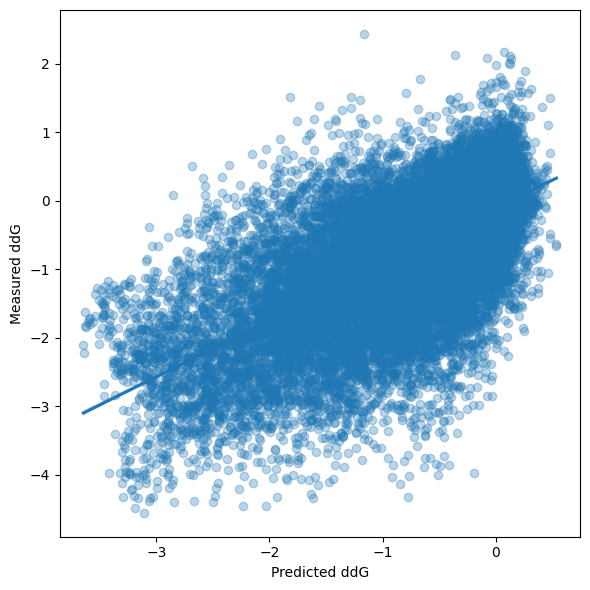

In [52]:
model.eval()
preds, all_y = [], []
with torch.no_grad():
    for x, y in loader_val:
        preds.append(model(x).squeeze().numpy())
        all_y.append(y.numpy())

preds = np.concatenate(preds)
all_y = np.concatenate(all_y)

print("RMSE:      ", skmetrics.mean_squared_error(all_y, preds))
print("Pearson r: ", scipy.stats.pearsonr(preds, all_y))
print("Spearman r:", scipy.stats.spearmanr(preds, all_y))

plt.figure(figsize=(6,6))
sns.regplot(x=preds, y=all_y, scatter_kws={'alpha':0.3})
plt.xlabel("Predicted ddG")
plt.ylabel("Measured ddG")
plt.tight_layout()
plt.show()

In [53]:
%reload_ext tensorboard
%tensorboard --logdir=lightning_logs


Reusing TensorBoard on port 6006 (pid 986870), started 17:15:02 ago. (Use '!kill 986870' to kill it.)

# Biological question:

In [54]:
def predict_ddG(mut_seq: str, wt_seq: str) -> float:
    """Predict ddG for any mutant/wildtype sequence pair."""
    model.eval()
    with torch.no_grad():
        x = build_input_vector(mut_seq, wt_seq).unsqueeze(0)  # (1, 1920)
        return model(x).item()

In [55]:
wt_sequence = str('MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRSSDFAKIINNTENLVRELLAVPDNYKVIFLQGGGCGQFSAVPLNLIGLKAGRCADYVVTGAWSAKAAEEAKKFGTINIVHPKLGSYTKIPDPSTWNLNPDASYVYYCANETVHGVEFDFIPDVKGAVLVCDMSSNFLSKPVDVSKFGVIFAGAQKNVGSAGVTVVIVRDDLLGFALRECPSVLEYKVQAGNSSLYNTPPCFSIYVMGLVLEWIKNNGGAAAMEKLSSIKSQTIYEIIDNSQGFYVCPVEPQNRSKMNIPFRIGNAKGDDALEKRFLDKALELNMLSLKGHRSVGGIRASLYNAVTIEDVQKLAAFMKKFLEMHQL')

df_predict = pd.read_csv('mutated_sequences_output.csv')
print(f"Loaded {len(df_predict)} mutations")
print(df_predict.head())


Loaded 199 mutations
      Mutation                                      Full_Sequence     score  \
0  p.Tyr249Cys  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.266467   
1  p.Glu366Asp  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.211577   
2  p.Lys311Asn  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.176802   
3  p.Ala359Thr  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.163540   
4  p.Ile351Val  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.159228   

         se  
0  0.030693  
1  0.033582  
2  0.035377  
3  0.034764  
4  0.029751  


In [56]:
model.eval()

predicted_ddG = []
for idx, row in df_predict.iterrows():
    mut_seq = row['Full_Sequence']
    ddg = predict_ddG(mut_seq, wt_sequence)
    predicted_ddG.append(ddg)
    if (idx + 1) % 10 == 0:
        print(f"  {idx + 1}/{len(df_predict)} done")

df_predict['ddG_predicted'] = predicted_ddG
print("Done!")
print(df_predict.head())

  10/199 done
  20/199 done
  30/199 done
  40/199 done
  50/199 done
  60/199 done
  70/199 done
  80/199 done
  90/199 done
  100/199 done
  110/199 done
  120/199 done
  130/199 done
  140/199 done
  150/199 done
  160/199 done
  170/199 done
  180/199 done
  190/199 done
Done!
      Mutation                                      Full_Sequence     score  \
0  p.Tyr249Cys  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.266467   
1  p.Glu366Asp  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.211577   
2  p.Lys311Asn  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.176802   
3  p.Ala359Thr  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.163540   
4  p.Ile351Val  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.159228   

         se  ddG_predicted  
0  0.030693      -0.579897  
1  0.033582      -0.020778  
2  0.035377      -0.039358  
3  0.034764      -0.057254  
4  0.029751       0.222657  


In [57]:
output_path = 'mutated_sequences_with_ddG.csv'
df_predict.to_csv(output_path, index=False)
print(f"Saved to {output_path}")
print(df_predict[['Mutation', 'Full_Sequence', 'score', 'se', 'ddG_predicted']].head(10))

Saved to mutated_sequences_with_ddG.csv
      Mutation                                      Full_Sequence     score  \
0  p.Tyr249Cys  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.266467   
1  p.Glu366Asp  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.211577   
2  p.Lys311Asn  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.176802   
3  p.Ala359Thr  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.163540   
4  p.Ile351Val  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.159228   
5  p.Glu113Val  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.155395   
6  p.Glu223Ala  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.154499   
7  p.Asn309Ser  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.152909   
8   p.Ala95Glu  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.151507   
9   p.Cys80Tyr  MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRS...  1.145226   

         se  ddG_predicted  
0  0.030693      -0.579897  
1  0.033582      -0.020778  
2  

Spearman ρ: 0.198  (p = 5.15e-03)
Kendall  τ: 0.134  (p = 4.89e-03)
Pearson  r: 0.202  (p = 4.22e-03)


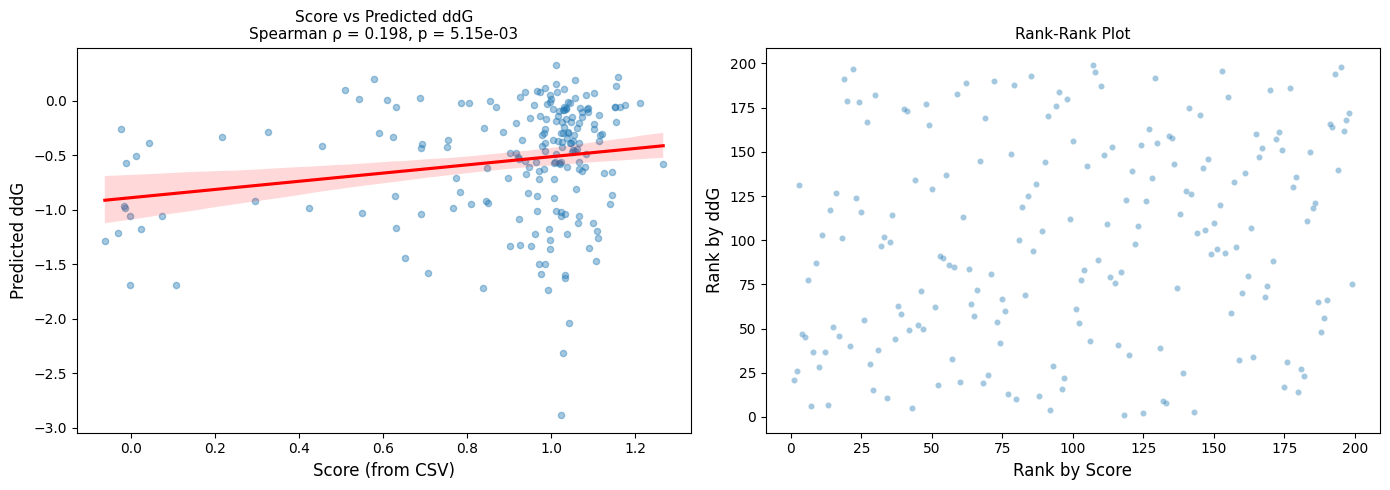


Top 10 by Score vs their ddG rank:
   Mutation    score  ddG_predicted  rank_ddG
p.Tyr249Cys 1.266467      -0.579897      75.0
p.Glu366Asp 1.211577      -0.020778     172.0
p.Lys311Asn 1.176802      -0.039358     168.0
p.Ala359Thr 1.163540      -0.057254     162.0
p.Ile351Val 1.159228       0.222657     198.0
p.Glu113Val 1.155395      -0.194154     140.0
p.Glu223Ala 1.154499       0.136800     194.0
p.Asn309Ser 1.152909      -0.056796     164.0
 p.Ala95Glu 1.151507      -0.053781     166.0
 p.Cys80Tyr 1.145226      -0.648836      66.0

Top 10 by ddG vs their score rank:
   Mutation  ddG_predicted    score  rank_score
p.Glu114Ala       0.327624 1.011224       107.0
p.Ile351Val       0.222657 1.159228       195.0
 p.Ala99Val       0.199871 0.577733        22.0
 p.Ile37Val       0.194609 1.055819       153.0
p.Ser275Cys       0.154529 1.011538       108.0
p.Glu223Ala       0.136800 1.154499       193.0
p.Leu217Val       0.123249 0.984392        85.0
p.His125Tyr       0.110604 1.031593   

In [58]:
df = pd.read_csv('mutated_sequences_with_ddG.csv')

# NOTE: ddG here is defined as dG(wt) - dG(mt)
# positive ddG = mutant less stable than WT
# flip sign below if needed:
# df['ddG_predicted'] = -df['ddG_predicted']

spearman = scipy.stats.spearmanr(df['score'], df['ddG_predicted'])
kendall  = scipy.stats.kendalltau(df['score'], df['ddG_predicted'])
pearson  = scipy.stats.pearsonr(df['score'],  df['ddG_predicted'])

print("=" * 45)
print(f"Spearman ρ: {spearman.statistic:.3f}  (p = {spearman.pvalue:.2e})")
print(f"Kendall  τ: {kendall.statistic:.3f}  (p = {kendall.pvalue:.2e})")
print(f"Pearson  r: {pearson.statistic:.3f}  (p = {pearson.pvalue:.2e})")
print("=" * 45)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter with regression line
ax = axes[0]
sns.regplot(
    data=df, x='score', y='ddG_predicted', ax=ax,
    scatter_kws={'alpha': 0.4, 's': 20},
    line_kws={'color': 'red'}
)
ax.set_xlabel("Score (from CSV)", fontsize=12)
ax.set_ylabel("Predicted ddG", fontsize=12)
ax.set_title(
    f"Score vs Predicted ddG\n"
    f"Spearman ρ = {spearman.statistic:.3f}, p = {spearman.pvalue:.2e}",
    fontsize=11
)

# Right: rank-rank scatter
ax2 = axes[1]
df['rank_score'] = df['score'].rank()
df['rank_ddG']   = df['ddG_predicted'].rank()
sns.scatterplot(
    data=df, x='rank_score', y='rank_ddG', ax=ax2,
    alpha=0.4, s=20
)
ax2.set_xlabel("Rank by Score", fontsize=12)
ax2.set_ylabel("Rank by ddG", fontsize=12)
ax2.set_title("Rank-Rank Plot", fontsize=11)

plt.tight_layout()
plt.savefig('data/score_vs_ddG_comparison.png', dpi=150)
plt.show()

# Top 10 comparisons
print("\nTop 10 by Score vs their ddG rank:")
top_score = df.nlargest(10, 'score')[['Mutation', 'score', 'ddG_predicted', 'rank_ddG']]
print(top_score.to_string(index=False))

print("\nTop 10 by ddG vs their score rank:")
top_ddg = df.nlargest(10, 'ddG_predicted')[['Mutation', 'ddG_predicted', 'score', 'rank_score']]
print(top_ddg.to_string(index=False))

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats
import re

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('mutated_sequences_with_ddG.csv')

wt_sequence = str("MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRSSDFAKIINNTENLVRELLAVPDNYKVIFLQGGGCGQFSAVPLNLIGLKAGRCADYVVTGAWSAKAAEEAKKFGTINIVHPKLGSYTKIPDPSTWNLNPDASYVYYCANETVHGVEFDFIPDVKGAVLVCDMSSNFLSKPVDVSKFGVIFAGAQKNVGSAGVTVVIVRDDLLGFALRECPSVLEYKVQAGNSSLYNTPPCFSIYVMGLVLEWIKNNGGAAAMEKLSSIKSQTIYEIIDNSQGFYVCPVEPQNRSKMNIPFRIGNAKGDDALEKRFLDKALELNMLSLKGHRSVGGIRASLYNAVTIEDVQKLAAFMKKFLEMHQL")

# ── Thresholds ────────────────────────────────────────────────────────────────
DDG_THRESH  = 0.0   # positive ddG = stabilizing = positive prediction
SCORE_THRESH = 1.0  # score > 1.0 = beneficial = positive ground truth

# Clip scores at 0 — below null control is just noise
df['score'] = df['score'].clip(lower=0.0)

# Use se to define confident ground truth labels
# Positive ground truth: score is significantly above 1.0
# Negative ground truth: score is significantly below 1.0
df['gt_positive'] = (df['score'] - 2 * df['se']) > SCORE_THRESH   # confidently > 1
df['gt_negative'] = (df['score'] + 2 * df['se']) < SCORE_THRESH   # confidently < 1
df['gt_uncertain'] = ~df['gt_positive'] & ~df['gt_negative']       # ambiguous around 1


In [60]:
def assign_category(row):
    pred_positive = row['ddG_predicted'] > DDG_THRESH  # positive ddG = stabilizing

    if row['gt_uncertain']:
        return 'UNCERTAIN'
    elif row['gt_positive']:
        # score > 1: beneficial mutation
        return 'TP' if pred_positive else 'FN'
    else:
        # score < 1: neutral/damaging mutation
        return 'FP' if pred_positive else 'TN'

df['category'] = df.apply(assign_category, axis=1)

In [61]:
COLOR_MAP = {
    'TP':        '#2ecc71',  # green  — score>1 + ddG>0 ✓
    'TN':        '#e74c3c',  # red    — score<1 + ddG<0 ✓
    'FP':        '#3498db',  # blue   — score<1 + ddG>0 ✗
    'FN':        '#e67e22',  # orange — score>1 + ddG<0 ✗
    'UNCERTAIN': '#95a5a6',  # grey   — score ~ 1.0
}

LABELS = {
    'TP':        'TP: score>1 + ddG>0 ✓',
    'TN':        'TN: score<1 + ddG<0 ✓',
    'FP':        'FP: score<1 + ddG>0 ✗',
    'FN':        'FN: score>1 + ddG<0 ✗',
    'UNCERTAIN': 'Uncertain: score ~ 1.0',
}

In [62]:
print("Category counts:")
print(df['category'].value_counts().to_string())

Category counts:
category
UNCERTAIN    92
TN           58
FN           39
FP            6
TP            4


In [63]:
tp = len(df[df['category'] == 'TP'])
tn = len(df[df['category'] == 'TN'])
fp = len(df[df['category'] == 'FP'])
fn = len(df[df['category'] == 'FN'])
total = tp + tn + fp + fn
if total > 0:
    accuracy  = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"\nAccuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")


Accuracy:  0.579
Precision: 0.400
Recall:    0.093


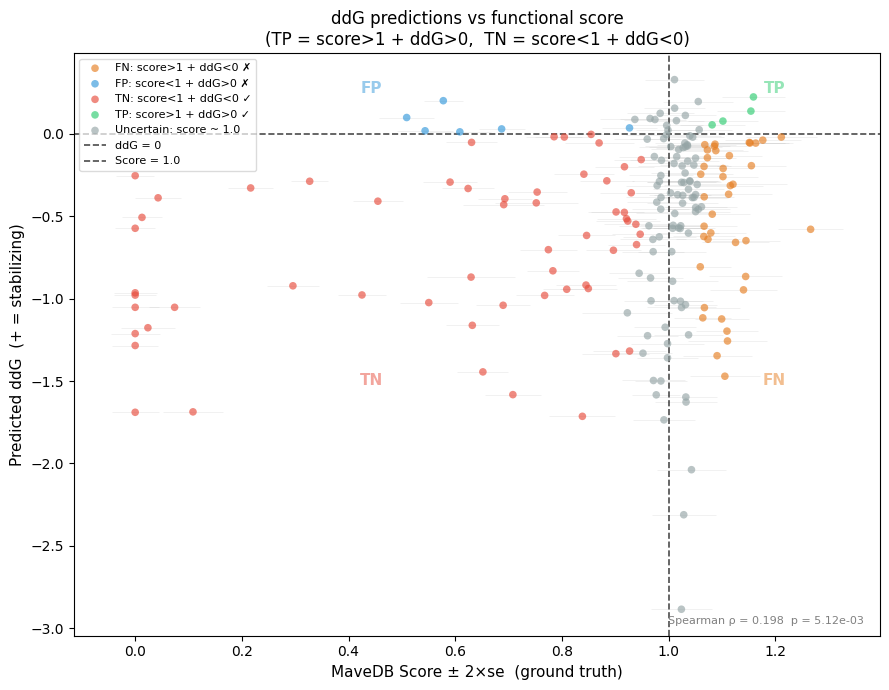

In [64]:
fig, ax = plt.subplots(figsize=(9, 7))

for cat, group in df.groupby('category'):
    ax.scatter(
        group['score'],
        group['ddG_predicted'],
        c=COLOR_MAP[cat],
        label=LABELS[cat],
        alpha=0.65, s=30, edgecolors='none', zorder=3
    )

# Score error bars
ax.errorbar(
    df['score'], df['ddG_predicted'],
    xerr=2 * df['se'].abs(),
    fmt='none', alpha=0.15, color='gray', linewidth=0.5, zorder=2
)

# Threshold lines
ax.axhline(DDG_THRESH,   color='black',  linestyle='--',
           linewidth=1.2, alpha=0.7, label='ddG = 0')
ax.axvline(SCORE_THRESH, color='black',  linestyle='--',
           linewidth=1.2, alpha=0.7, label='Score = 1.0')

# Region labels
xlim = ax.get_xlim()
ylim = ax.get_ylim()
mid_y_top = (ylim[1] + DDG_THRESH) / 2
mid_y_bot = (ylim[0] + DDG_THRESH) / 2
mid_x_left  = (xlim[0] + SCORE_THRESH) / 2
mid_x_right = (xlim[1] + SCORE_THRESH) / 2

for x, y, txt in [
    (mid_x_right, mid_y_top, 'TP'),
    (mid_x_left,  mid_y_bot, 'TN'),
    (mid_x_left,  mid_y_top, 'FP'),
    (mid_x_right, mid_y_bot, 'FN'),
]:
    ax.text(x, y, txt, ha='center', fontsize=11,
            color=COLOR_MAP[txt], fontweight='bold', alpha=0.5)

spearman = scipy.stats.spearmanr(df['score'], df['ddG_predicted'])
ax.text(0.98, 0.02,
        f"Spearman ρ = {spearman.statistic:.3f}  p = {spearman.pvalue:.2e}",
        transform=ax.transAxes, ha='right', fontsize=8, color='gray')

ax.set_xlabel("MaveDB Score ± 2×se  (ground truth)", fontsize=11)
ax.set_ylabel("Predicted ddG  (+ = stabilizing)", fontsize=11)
ax.set_title("ddG predictions vs functional score\n"
             "(TP = score>1 + ddG>0,  TN = score<1 + ddG<0)",
             fontsize=12)
ax.legend(fontsize=8, loc='upper left', framealpha=0.7)
plt.tight_layout()
plt.savefig('outputs/quadrant_scatter_final.png', dpi=150)
plt.show()

In [65]:
print(f"Negative se values: {(df['se'] < 0).sum()}")
print(f"Min se: {df['se'].min():.4f}")
print(df[df['se'] < 0][['Mutation', 'score', 'se']].head(10))

Negative se values: 8
Min se: -0.0231
        Mutation  score        se
191  p.Arg342Gln    0.0 -0.022029
192  p.Thr242Met    0.0 -0.022045
193   p.Gly36Arg    0.0 -0.018566
194  p.Ser147Tyr    0.0 -0.019915
195  p.Thr156Met    0.0 -0.020179
196  p.Ser179Leu    0.0 -0.018090
197  p.Gly203Arg    0.0 -0.023093
198  p.Gly206Arg    0.0 -0.021557


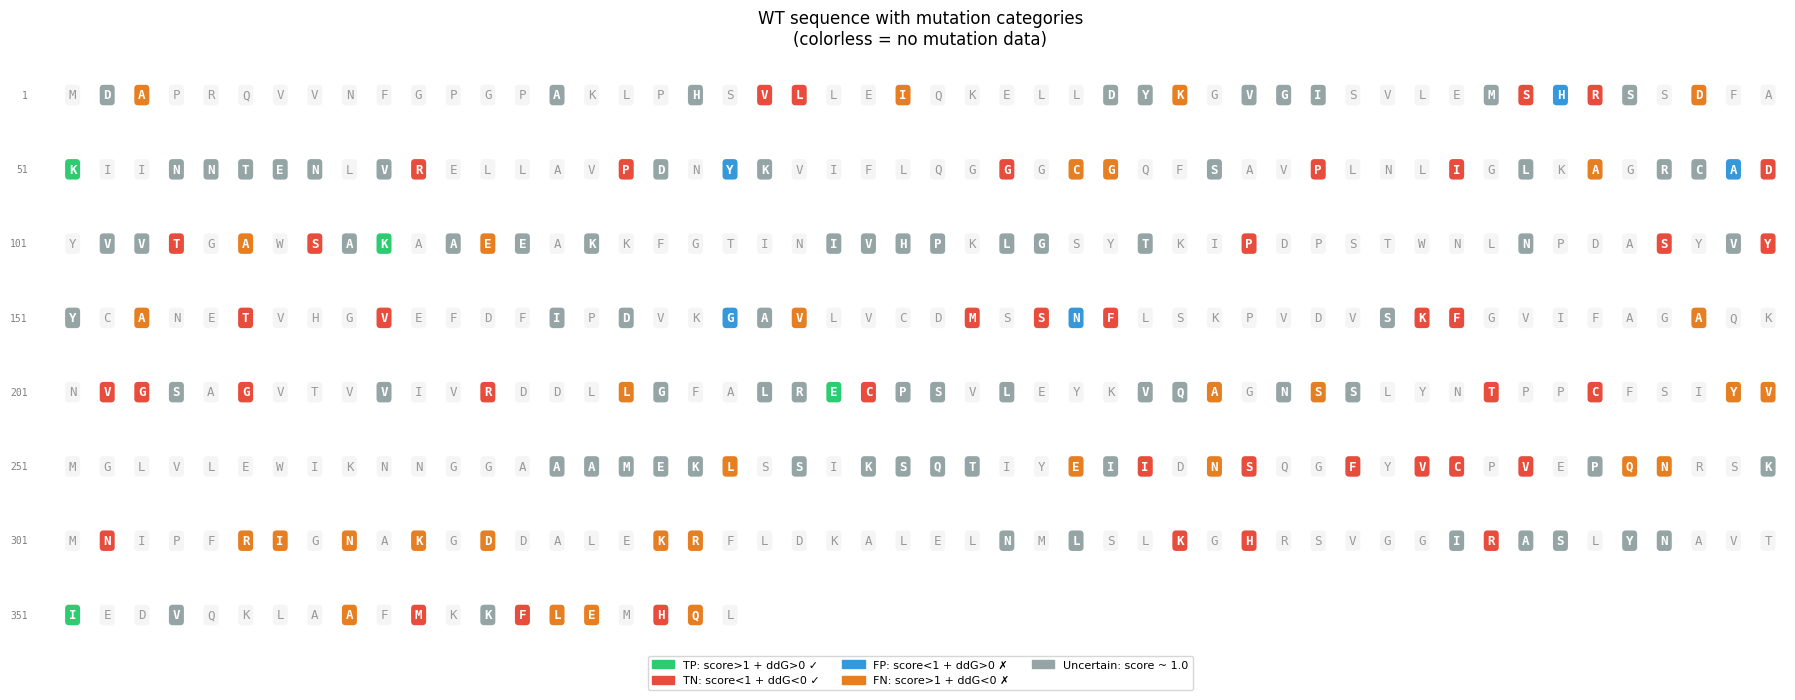

Saved to outputs/colourindex_wtseq.png


In [67]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('outputs', exist_ok=True)

# Build position → category lookup
pos_to_cat = dict(zip(pos_category['position'], pos_category['dominant_category']))

# ── Layout: wrap sequence into rows of N characters ──────────────────────────
CHARS_PER_ROW = 50
rows = [wt_sequence[i:i+CHARS_PER_ROW] for i in range(0, len(wt_sequence), CHARS_PER_ROW)]
n_rows = len(rows)

fig, ax = plt.subplots(figsize=(18, n_rows * 0.7 + 1.5))
ax.set_xlim(0, CHARS_PER_ROW)
ax.set_ylim(-0.5, n_rows)
ax.axis('off')

for row_idx, row_seq in enumerate(rows):
    y = n_rows - row_idx - 1  # top to bottom
    for col_idx, aa in enumerate(row_seq):
        pos = row_idx * CHARS_PER_ROW + col_idx + 1  # 1-indexed
        cat = pos_to_cat.get(pos, None)

        if cat is not None:
            facecolor = COLOR_MAP[cat]
            textcolor = 'white'
            fontweight = 'bold'
        else:
            facecolor = '#f5f5f5'
            textcolor = '#999999'
            fontweight = 'normal'

        ax.text(
            col_idx + 0.5, y + 0.5, aa,
            ha='center', va='center',
            fontsize=9, fontweight=fontweight, color=textcolor,
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=facecolor, edgecolor='none')
        )

    # Row position label on the left
    start_pos = row_idx * CHARS_PER_ROW + 1
    ax.text(-0.8, y + 0.5, str(start_pos),
            ha='right', va='center', fontsize=7, color='gray', fontfamily='monospace')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COLOR_MAP[cat], label=LABELS[cat])
    for cat in ['TP', 'TN', 'FP', 'FN', 'UNCERTAIN']
]
ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08 * (1 / n_rows)),
    ncol=3, fontsize=8, framealpha=0.8
)

ax.set_title("WT sequence with mutation categories\n(colorless = no mutation data)",
             fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('outputs/colourindex_wtseq.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/colourindex_wtseq.png")

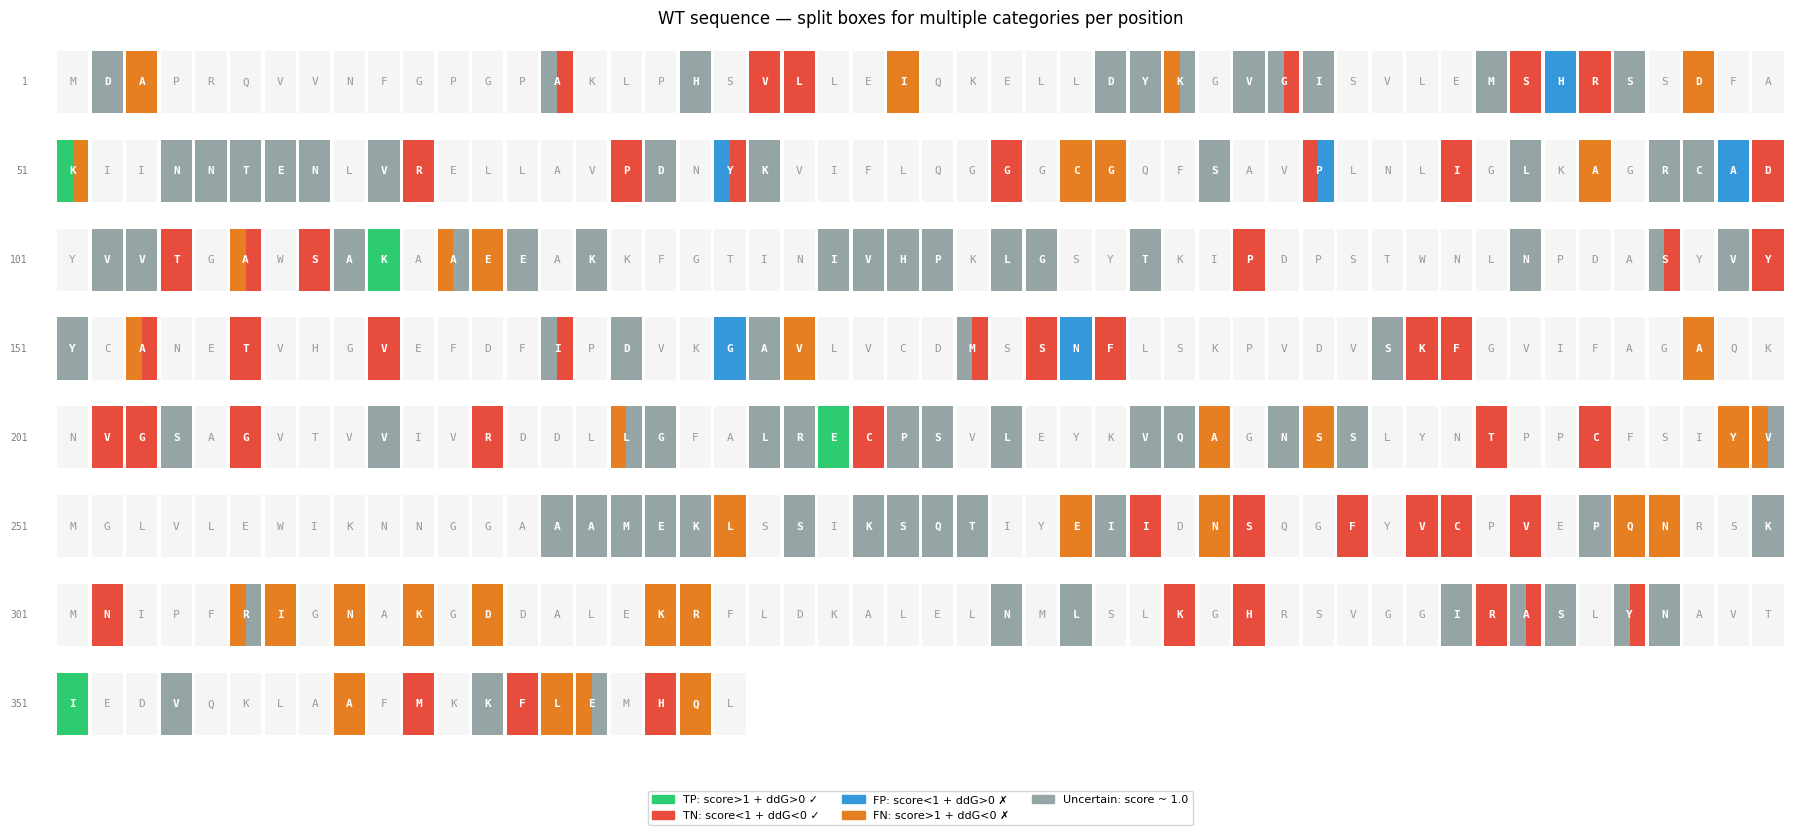

Saved to outputs/colourindex_split.png


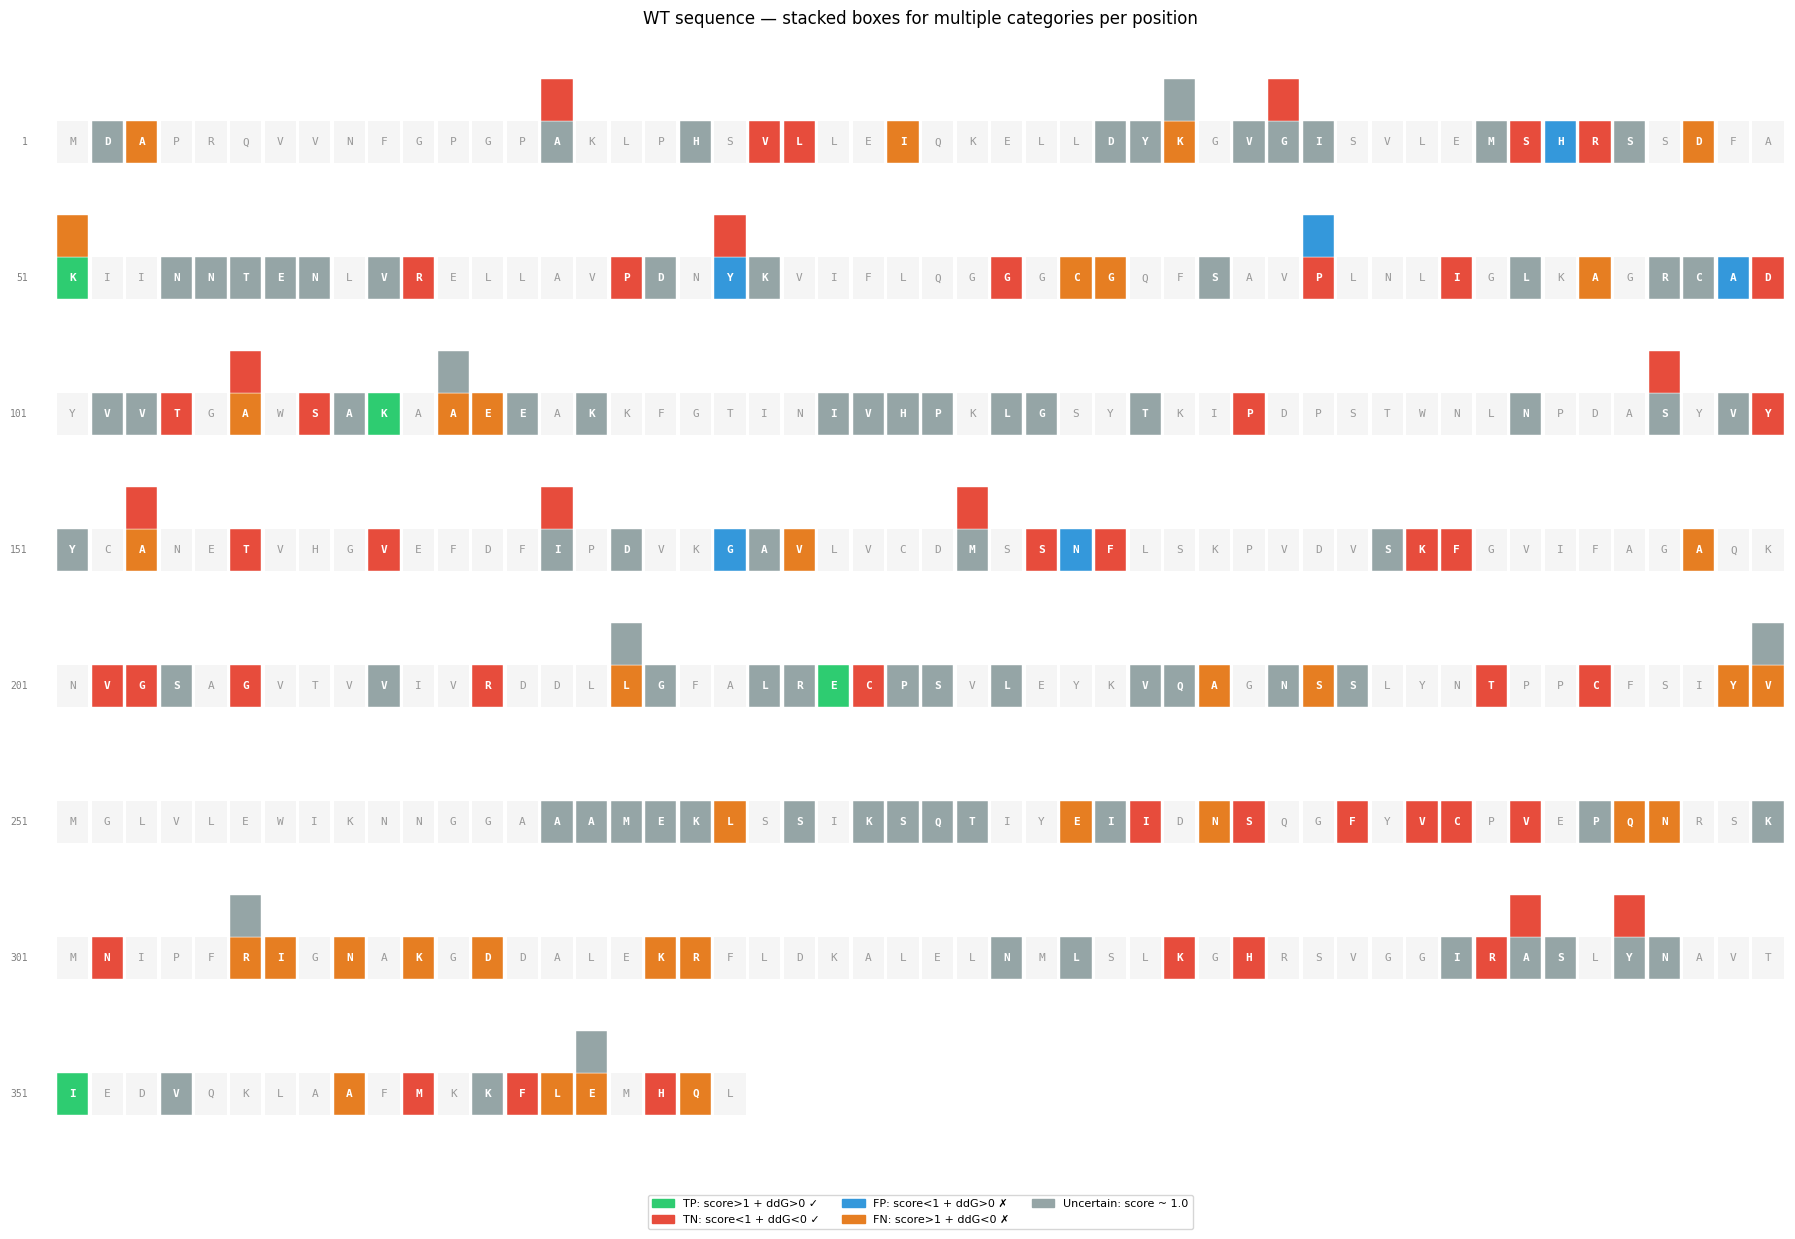

Saved to outputs/colourindex_stacked.png


In [68]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import os

os.makedirs('outputs', exist_ok=True)

CHARS_PER_ROW = 50

# ── Build per-position category list (all categories, not just dominant) ──────
pos_all_cats = (
    df.groupby('position')['category']
    .apply(list)
    .reset_index()
    .rename(columns={'category': 'all_categories'})
)
pos_all_cats['unique_cats'] = pos_all_cats['all_categories'].apply(
    lambda x: list(dict.fromkeys(x))  # unique, preserving order
)
pos_to_cats = dict(zip(pos_all_cats['position'], pos_all_cats['unique_cats']))

rows = [wt_sequence[i:i+CHARS_PER_ROW] for i in range(0, len(wt_sequence), CHARS_PER_ROW)]
n_rows = len(rows)


# ════════════════════════════════════════════════════════════════════════════════
# Plot A: Split boxes (side by side within one cell)
# ════════════════════════════════════════════════════════════════════════════════
fig_a, ax_a = plt.subplots(figsize=(18, n_rows * 0.8 + 2))
ax_a.set_xlim(0, CHARS_PER_ROW)
ax_a.set_ylim(-0.5, n_rows)
ax_a.axis('off')

BOX_W = 0.9   # total width of one character cell
BOX_H = 0.7   # total height

for row_idx, row_seq in enumerate(rows):
    y = n_rows - row_idx - 1
    for col_idx, aa in enumerate(row_seq):
        pos  = row_idx * CHARS_PER_ROW + col_idx + 1
        cats = pos_to_cats.get(pos, None)
        cx   = col_idx + 0.5   # centre x of cell

        if cats is None:
            # Unmutated — single grey box
            ax_a.add_patch(plt.Rectangle(
                (cx - BOX_W/2, y + 0.5 - BOX_H/2), BOX_W, BOX_H,
                facecolor='#f5f5f5', edgecolor='none', zorder=1
            ))
            ax_a.text(cx, y + 0.5, aa, ha='center', va='center',
                      fontsize=8, color='#999999', fontfamily='monospace')

        elif len(cats) == 1:
            # Single category — normal full box
            ax_a.add_patch(plt.Rectangle(
                (cx - BOX_W/2, y + 0.5 - BOX_H/2), BOX_W, BOX_H,
                facecolor=COLOR_MAP[cats[0]], edgecolor='none', zorder=1
            ))
            ax_a.text(cx, y + 0.5, aa, ha='center', va='center',
                      fontsize=8, color='white', fontweight='bold',
                      fontfamily='monospace')

        else:
            # Multiple categories — split box horizontally
            n     = len(cats)
            sw    = BOX_W / n   # width of each split
            for k, cat in enumerate(cats):
                x0 = cx - BOX_W/2 + k * sw
                ax_a.add_patch(plt.Rectangle(
                    (x0, y + 0.5 - BOX_H/2), sw, BOX_H,
                    facecolor=COLOR_MAP[cat], edgecolor='none', zorder=1
                ))
            # AA letter centered over the split box
            ax_a.text(cx, y + 0.5, aa, ha='center', va='center',
                      fontsize=8, color='white', fontweight='bold',
                      fontfamily='monospace', zorder=2)

    # Row position label
    ax_a.text(-0.8, y + 0.5, str(row_idx * CHARS_PER_ROW + 1),
              ha='right', va='center', fontsize=7, color='gray',
              fontfamily='monospace')

legend_handles = [
    mpatches.Patch(color=COLOR_MAP[cat], label=LABELS[cat])
    for cat in ['TP', 'TN', 'FP', 'FN', 'UNCERTAIN']
]
ax_a.legend(handles=legend_handles, loc='lower center',
            bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=8, framealpha=0.8)
ax_a.set_title("WT sequence — split boxes for multiple categories per position",
               fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('outputs/colourindex_split.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to outputs/colourindex_split.png")


# ════════════════════════════════════════════════════════════════════════════════
# Plot B: Stacked boxes (one on top of the other)
# ════════════════════════════════════════════════════════════════════════════════

# For stacked plot, scale row height by max number of categories at any position
max_cats = max(
    (len(cats) for cats in pos_to_cats.values()),
    default=1
)
ROW_H   = max_cats * 0.5 + 0.3   # height per sequence row
SLICE_H = 0.4                     # height of each stacked slice

fig_b, ax_b = plt.subplots(figsize=(18, n_rows * ROW_H + 2))
ax_b.set_xlim(0, CHARS_PER_ROW)
ax_b.set_ylim(-0.5, n_rows * ROW_H)
ax_b.axis('off')

for row_idx, row_seq in enumerate(rows):
    y_base = (n_rows - row_idx - 1) * ROW_H   # bottom of this sequence row
    for col_idx, aa in enumerate(row_seq):
        pos  = row_idx * CHARS_PER_ROW + col_idx + 1
        cats = pos_to_cats.get(pos, None)
        cx   = col_idx + 0.5

        if cats is None:
            # Single grey box
            ax_b.add_patch(plt.Rectangle(
                (cx - BOX_W/2, y_base + 0.1), BOX_W, SLICE_H,
                facecolor='#f5f5f5', edgecolor='none', zorder=1
            ))
            ax_b.text(cx, y_base + 0.1 + SLICE_H/2, aa,
                      ha='center', va='center', fontsize=8,
                      color='#999999', fontfamily='monospace')

        else:
            # Stack slices bottom to top
            for k, cat in enumerate(cats):
                y0 = y_base + 0.1 + k * SLICE_H
                ax_b.add_patch(plt.Rectangle(
                    (cx - BOX_W/2, y0), BOX_W, SLICE_H,
                    facecolor=COLOR_MAP[cat], edgecolor='white',
                    linewidth=0.3, zorder=1
                ))
            # AA letter on the bottom slice
            ax_b.text(cx, y_base + 0.1 + SLICE_H/2, aa,
                      ha='center', va='center', fontsize=8,
                      color='white', fontweight='bold',
                      fontfamily='monospace', zorder=2)

    # Row position label
    ax_b.text(-0.8, y_base + 0.1 + SLICE_H/2,
              str(row_idx * CHARS_PER_ROW + 1),
              ha='right', va='center', fontsize=7, color='gray',
              fontfamily='monospace')

ax_b.legend(handles=legend_handles, loc='lower center',
            bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=8, framealpha=0.8)
ax_b.set_title("WT sequence — stacked boxes for multiple categories per position",
               fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('outputs/colourindex_stacked.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to outputs/colourindex_stacked.png")

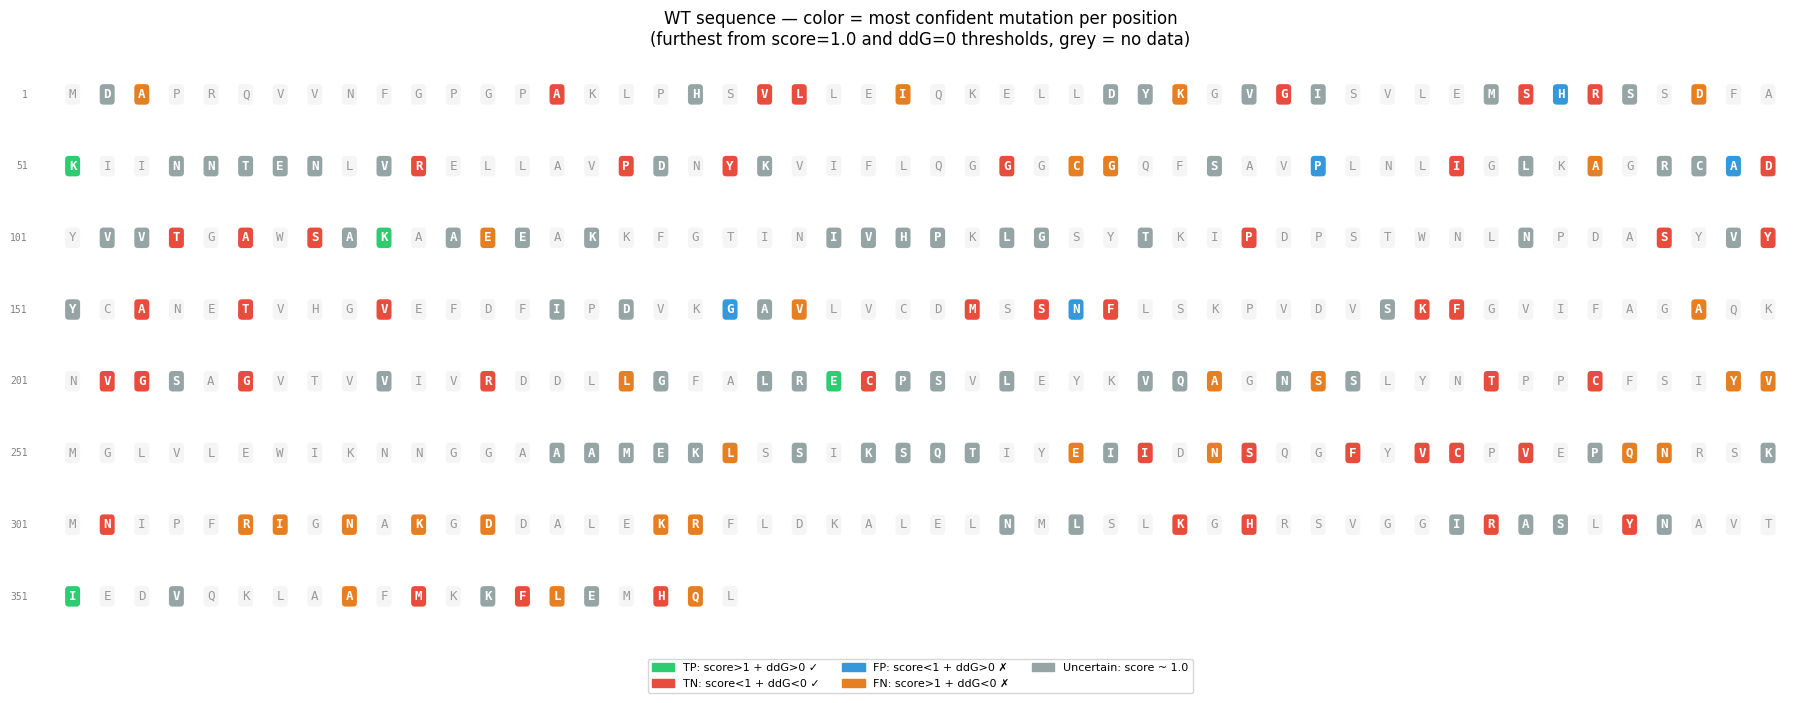

Saved to outputs/colourindex_mostconfident.png

Most confident mutation per position:
  Position    2 (D): UNCERTAIN    score=1.035  ddG=-0.068  dist=0.103
  Position    3 (A): FN           score=1.086  ddG=-0.077  dist=0.163
  Position   15 (A): TN           score=0.850  ddG=-0.939  dist=1.089
  Position   19 (H): UNCERTAIN    score=0.975  ddG=0.086  dist=0.111
  Position   21 (V): TN           score=0.901  ddG=-1.334  dist=1.433
  Position   22 (L): TN           score=0.551  ddG=-1.024  dist=1.474
  Position   25 (I): FN           score=1.100  ddG=-1.124  dist=1.223
  Position   31 (D): UNCERTAIN    score=1.058  ddG=0.024  dist=0.081
  Position   32 (Y): UNCERTAIN    score=1.062  ddG=-0.443  dist=0.505
  Position   33 (K): FN           score=1.060  ddG=-0.246  dist=0.306
  Position   35 (V): UNCERTAIN    score=1.051  ddG=-0.473  dist=0.524
  Position   36 (G): TN           score=0.000  ddG=-0.574  dist=1.574
  Position   37 (I): UNCERTAIN    score=1.056  ddG=0.195  dist=0.250
  Posit

In [69]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('outputs', exist_ok=True)

CHARS_PER_ROW = 50

# ── For each position, pick mutation furthest from both thresholds ─────────────
df['dist_score'] = (df['score'] - SCORE_THRESH).abs()
df['dist_ddg']   = (df['ddG_predicted'] - DDG_THRESH).abs()
df['dist_total'] = df['dist_score'] + df['dist_ddg']

# Per position: row with maximum combined distance
pos_most_confident = (
    df.loc[df.groupby('position')['dist_total'].idxmax()]
    [['position', 'category', 'dist_total', 'score', 'ddG_predicted']]
    .reset_index(drop=True)
)
pos_to_cat = dict(zip(pos_most_confident['position'],
                      pos_most_confident['category']))

# ── Plot ──────────────────────────────────────────────────────────────────────
rows  = [wt_sequence[i:i+CHARS_PER_ROW]
         for i in range(0, len(wt_sequence), CHARS_PER_ROW)]
n_rows = len(rows)

fig, ax = plt.subplots(figsize=(18, n_rows * 0.7 + 1.5))
ax.set_xlim(0, CHARS_PER_ROW)
ax.set_ylim(-0.5, n_rows)
ax.axis('off')

for row_idx, row_seq in enumerate(rows):
    y = n_rows - row_idx - 1
    for col_idx, aa in enumerate(row_seq):
        pos = row_idx * CHARS_PER_ROW + col_idx + 1
        cat = pos_to_cat.get(pos, None)

        if cat is not None:
            facecolor  = COLOR_MAP[cat]
            textcolor  = 'white'
            fontweight = 'bold'
        else:
            facecolor  = '#f5f5f5'
            textcolor  = '#999999'
            fontweight = 'normal'

        ax.text(
            col_idx + 0.5, y + 0.5, aa,
            ha='center', va='center',
            fontsize=9, fontweight=fontweight, color=textcolor,
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor=facecolor, edgecolor='none')
        )

    # Row position label
    ax.text(-0.8, y + 0.5, str(row_idx * CHARS_PER_ROW + 1),
            ha='right', va='center', fontsize=7, color='gray',
            fontfamily='monospace')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COLOR_MAP[cat], label=LABELS[cat])
    for cat in ['TP', 'TN', 'FP', 'FN', 'UNCERTAIN']
]
ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3, fontsize=8, framealpha=0.8
)
ax.set_title(
    "WT sequence — color = most confident mutation per position\n"
    "(furthest from score=1.0 and ddG=0 thresholds, grey = no data)",
    fontsize=12, pad=10
)

plt.tight_layout()
plt.savefig('outputs/colourindex_mostconfident.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to outputs/colourindex_mostconfident.png")

# ── Print summary ─────────────────────────────────────────────────────────────
print("\nMost confident mutation per position:")
for _, row in pos_most_confident.sort_values('position').iterrows():
    pos = int(row['position'])
    aa  = wt_sequence[pos-1] if 1 <= pos <= len(wt_sequence) else '?'
    print(f"  Position {pos:4d} ({aa}): {row['category']:12s} "
          f"score={row['score']:.3f}  ddG={row['ddG_predicted']:.3f}  "
          f"dist={row['dist_total']:.3f}")

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import scipy.stats
import os

os.makedirs('outputs', exist_ok=True)

# ── Monte Carlo Dropout for ddG uncertainty ───────────────────────────────────
N_SAMPLES = 30  # number of stochastic forward passes

def predict_ddG_mc(mut_seq: str, wt_seq: str, n_samples: int = N_SAMPLES):
    """
    Returns (mean_ddG, se_ddG) using Monte Carlo dropout.
    Model must have dropout layers for this to work.
    """
    model.train()  # dropout ON
    preds = []
    with torch.no_grad():
        x = build_input_vector(mut_seq, wt_seq).unsqueeze(0)
        for _ in range(n_samples):
            preds.append(model(x).item())
    model.eval()   # restore eval mode
    preds = np.array(preds)
    return preds.mean(), preds.std() / np.sqrt(n_samples)  # mean, SE

# Compute MC dropout uncertainty for all rows
print("Computing MC dropout uncertainty...")
ddg_means, ddg_ses = [], []
for idx, row in df.iterrows():
    mean, se = predict_ddG_mc(row['Full_Sequence'], wt_sequence)
    ddg_means.append(mean)
    ddg_ses.append(se)
    if (idx + 1) % 50 == 0:
        print(f"  {idx + 1}/{len(df)} done")

df['ddG_mean'] = ddg_means
df['ddG_se']   = ddg_ses
print("Done!")

# ── Redefine thresholds & categories using uncertainty on BOTH axes ───────────
SCORE_THRESH = 1.0
DDG_THRESH   = 0.0

# Score: confident if 2*se doesn't cross threshold
df['score_confident_high'] = (df['score'] - 2 * df['se'].abs()) > SCORE_THRESH
df['score_confident_low']  = (df['score'] + 2 * df['se'].abs()) < SCORE_THRESH
df['score_uncertain']      = ~df['score_confident_high'] & ~df['score_confident_low']

# ddG: confident if 2*se doesn't cross zero
df['ddg_confident_pos'] = (df['ddG_mean'] - 2 * df['ddG_se']) > DDG_THRESH
df['ddg_confident_neg'] = (df['ddG_mean'] + 2 * df['ddG_se']) < DDG_THRESH
df['ddg_uncertain']     = ~df['ddg_confident_pos'] & ~df['ddg_confident_neg']

# ── Assign categories (renamed — no more TP/FP/FN/TN) ────────────────────────
def assign_category(row):
    score_hi  = row['score_confident_high']
    score_lo  = row['score_confident_low']
    score_unc = row['score_uncertain']
    ddg_pos   = row['ddg_confident_pos']
    ddg_neg   = row['ddg_confident_neg']
    ddg_unc   = row['ddg_uncertain']

    if score_unc or ddg_unc:
        return 'UNCERTAIN'
    elif score_hi and ddg_pos:
        return 'HYPER_STAB'      # hyperactive + stabilizing
    elif score_hi and ddg_neg:
        return 'HYPER_DESTAB'    # hyperactive + destabilizing
    elif score_lo and ddg_neg:
        return 'DAM_DESTAB'      # damaging + destabilizing
    elif score_lo and ddg_pos:
        return 'DAM_STAB'        # damaging + stabilizing
    else:
        return 'UNCERTAIN'

df['category'] = df.apply(assign_category, axis=1)

COLOR_MAP = {
    'HYPER_STAB':   '#2ecc71',  # green  — hyperactive + stabilizing
    'HYPER_DESTAB': '#e74c3c',  # red    — hyperactive + destabilizing
    'DAM_DESTAB':   '#3498db',  # blue   — damaging + destabilizing
    'DAM_STAB':     '#e67e22',  # orange — damaging + stabilizing
    'UNCERTAIN':    '#95a5a6',  # grey   — uncertain on either axis
}

LABELS = {
    'HYPER_STAB':   'Hyperactive + stabilizing',
    'HYPER_DESTAB': 'Hyperactive + destabilizing',
    'DAM_DESTAB':   'Damaging + destabilizing',
    'DAM_STAB':     'Damaging + stabilizing',
    'UNCERTAIN':    'Uncertain (overlaps threshold)',
}

print("\nCategory counts:")
print(df['category'].value_counts().to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

for cat, group in df.groupby('category'):
    ax.scatter(
        group['score'],
        group['ddG_mean'],
        c=COLOR_MAP[cat],
        label=LABELS[cat],
        alpha=0.7, s=35, edgecolors='none', zorder=3
    )

# Error bars — both axes
ax.errorbar(
    df['score'], df['ddG_mean'],
    xerr=2 * df['se'].abs(),
    yerr=2 * df['ddG_se'],
    fmt='none', alpha=0.15, color='gray', linewidth=0.5, zorder=2
)

# Threshold lines
ax.axhline(DDG_THRESH,   color='black', linestyle='--',
           linewidth=1.2, alpha=0.7, label='ddG = 0')
ax.axvline(SCORE_THRESH, color='black', linestyle='--',
           linewidth=1.2, alpha=0.7, label='Score = 1.0')

spearman = scipy.stats.spearmanr(df['score'], df['ddG_mean'])
ax.text(0.98, 0.02,
        f"Spearman ρ = {spearman.statistic:.3f}  p = {spearman.pvalue:.2e}",
        transform=ax.transAxes, ha='right', fontsize=8, color='gray')

ax.set_xlabel("MaveDB Score ± 2×se  (ground truth)", fontsize=11)
ax.set_ylabel("Predicted ddG ± 2×se  (+ = stabilizing)", fontsize=11)
ax.set_title("Predicted ddG vs functional score\n"
             "(grey = uncertain on score or ddG axis)",
             fontsize=12)
ax.legend(fontsize=8, loc='upper left', framealpha=0.7)

plt.tight_layout()
plt.savefig('outputs/quadrant_scatter_uncertainty.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to outputs/quadrant_scatter_uncertainty.png")

Computing MC dropout uncertainty...


NameError: name 'model' is not defined

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('outputs', exist_ok=True)

CHARS_PER_ROW = 50

# ── For each position, pick mutation furthest from both thresholds ─────────────
df['dist_score'] = (df['score'] - SCORE_THRESH).abs()
df['dist_ddg']   = (df['ddG_mean'] - DDG_THRESH).abs()
df['dist_total'] = df['dist_score'] + df['dist_ddg']

pos_most_confident = (
    df.loc[df.groupby('position')['dist_total'].idxmax()]
    [['position', 'category', 'dist_total', 'score', 'ddG_mean', 'ddG_se']]
    .reset_index(drop=True)
)
pos_to_cat = dict(zip(pos_most_confident['position'],
                      pos_most_confident['category']))

# ── Plot ──────────────────────────────────────────────────────────────────────
rows   = [wt_sequence[i:i+CHARS_PER_ROW]
          for i in range(0, len(wt_sequence), CHARS_PER_ROW)]
n_rows = len(rows)

fig, ax = plt.subplots(figsize=(18, n_rows * 0.7 + 2))
ax.set_xlim(0, CHARS_PER_ROW)
ax.set_ylim(-0.5, n_rows)
ax.axis('off')

for row_idx, row_seq in enumerate(rows):
    y = n_rows - row_idx - 1
    for col_idx, aa in enumerate(row_seq):
        pos = row_idx * CHARS_PER_ROW + col_idx + 1
        cat = pos_to_cat.get(pos, None)

        if cat is not None:
            facecolor  = COLOR_MAP[cat]
            textcolor  = 'white'
            fontweight = 'bold'
        else:
            facecolor  = '#f5f5f5'
            textcolor  = '#999999'
            fontweight = 'normal'

        ax.text(
            col_idx + 0.5, y + 0.5, aa,
            ha='center', va='center',
            fontsize=9, fontweight=fontweight, color=textcolor,
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor=facecolor, edgecolor='none')
        )

    # Row position label
    ax.text(-0.8, y + 0.5, str(row_idx * CHARS_PER_ROW + 1),
            ha='right', va='center', fontsize=7,
            color='gray', fontfamily='monospace')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COLOR_MAP[cat], label=LABELS[cat])
    for cat in ['HYPER_STAB', 'HYPER_DESTAB', 'DAM_DESTAB', 'DAM_STAB', 'UNCERTAIN']
]
ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3, fontsize=8, framealpha=0.8
)
ax.set_title(
    "WT sequence — most confident mutation per position\n"
    "(grey = no data, light grey box = uncertain on score or ddG axis)",
    fontsize=12, pad=10
)

plt.tight_layout()
plt.savefig('outputs/colourindex_uncertainty.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to outputs/colourindex_uncertainty.png")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\nMost confident mutation per position:")
for _, row in pos_most_confident.sort_values('position').iterrows():
    pos = int(row['position'])
    aa  = wt_sequence[pos-1] if 1 <= pos <= len(wt_sequence) else '?'
    print(f"  Position {pos:4d} ({aa}): {row['category']:15s} "
          f"score={row['score']:.3f}  "
          f"ddG={row['ddG_mean']:.3f} ± {2*row['ddG_se']:.3f}  "
          f"dist={row['dist_total']:.3f}")